# 1. Подключение библиотек

In [2]:
import pyreadstat
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from sklearn.model_selection import GridSearchCV
import joblib

# 2. Инициализация функций и некоторых переменных

In [5]:
def calculate_comprehensive_metrics(y_true, y_pred, y_pred_proba, model_name):
    return {
        'Model': model_name,
        'AUC': roc_auc_score(y_true, y_pred_proba),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }
def unique_values_cols(df):
    for col in columns.values():
        print(col,' ---> ',df[col].unique())

def encode_personality_traits(df):
    """
    Высшие значения = более выраженная черта (в контексте риска алкоголизма)
    """
    
    # 1. ЧЕРТЫ, где ВЫСОКИЕ значения = ВЫСОКИЙ РИСК алкоголизма
    risk_enhancing_traits = {
        # Импульсивность, низкий самоконтроль
        'preference_leisure': 'bbj445.12',  # Предпочтение досуга работе
        'nervousness': 'bbj445.18',         # Нервозность
        'anxiety': 'bbj445.10',             # Тревожность
        'perceived_hostility': 'bbj445.22', # Воспринимаемая враждебность
        'exploitability': 'bbj445.7',       # Склонность позволять другим пользоваться собой
    }
    
    # 2. ЧЕРТЫ, где ВЫСОКИЕ значения = НИЗКИЙ РИСК алкоголизма (нужно ИНВЕРТИРОВАТЬ)
    risk_protective_traits = {
        # Самоконтроль, устойчивость
        'stress_tolerance': 'bbj445.5',     # Устойчивость к стрессу
        'task_completion': 'bbj445.6',      # Доведение задач до конца  
        'work_ethic': 'bbj445.8',           # Трудовая этика
        'work_efficiency': 'bbj445.17',     # Эффективность в работе
        'decision_carefulness': 'bbj445.21', # Осторожность в решениях
        'long_term_focus': 'bbj445.13',     # Ориентация на долгосрочные цели
        'future_orientation': 'bbj445.15',  # Ориентация на будущее
    }
    
    # 3. НЕЙТРАЛЬНЫЕ черты (кодируем как есть для анализа)
    neutral_traits = {
        'talkativeness': 'bbj445.1',
        'work_accuracy': 'bbj445.2', 
        'creativity': 'bbj445.3',
        'reserved_opinions': 'bbj445.4',
        'forgiveness': 'bbj445.9',
        'curiosity': 'bbj445.11',
        'aesthetic_appreciation': 'bbj445.14',
        'politeness': 'bbj445.16',
        'generosity': 'bbj445.19',
        'sociability': 'bbj445.20',
    }
    
    # КОДИРОВАНИЕ:
    
    # Риск-усиливающие: оставляем как есть (1-4, где 1 = "Почти всегда" рисковой черты)
    for new_name, old_name in risk_enhancing_traits.items():
        if old_name in df.columns:
            df[new_name] = df[old_name]
            # Очистка от специальных значений
            df[new_name] = df[new_name].replace({88888888: np.nan, 99999996: np.nan, 
                                               99999997: np.nan, 99999998: np.nan, 99999999: np.nan})
    
    # Риск-защитные: ИНВЕРТИРУЕМ (1→4, 2→3, 3→2, 4→1)
    # Чтобы высокие значения = высокая защита (низкий риск)
    for new_name, old_name in risk_protective_traits.items():
        if old_name in df.columns:
            df[new_name] = df[old_name].map({1: 4, 2: 3, 3: 2, 4: 1, 
                                           88888888: np.nan, 99999996: np.nan,
                                           99999997: np.nan, 99999998: np.nan, 99999999: np.nan})
    
    # Нейтральные: оставляем как есть для исследования
    for new_name, old_name in neutral_traits.items():
        if old_name in df.columns:
            df[new_name] = df[old_name]
            df[new_name] = df[new_name].replace({88888888: np.nan, 99999996: np.nan,
                                               99999997: np.nan, 99999998: np.nan, 99999999: np.nan})
    
    return df


def create_comprehensive_alcohol_index(df):
    """
    Обновленная версия с правильным кодированием
    """
    df['alcohol_comprehensive_score'] = 0
    
    # 1. ПРЯМЫЕ АЛКОГОЛЬНЫЕ МАРКЕРЫ 
    alcohol_markers = {
        'alcohol_use': 2,
        'alcohol_at_work': 3, 
        'alcohol_without_meal': 2,
        'alcohol_before_meal': 1,
        'alcohol_outdoors': 1,
    }
    
    for marker, weight in alcohol_markers.items():
        if marker in df.columns:
            df['alcohol_comprehensive_score'] += (df[marker] == 1).astype(int) * weight
    
    # 2. ЛИЧНОСТНЫЕ ЧЕРТЫ (теперь с правильным кодированием)
    # Высокие значения = высокий риск
    personality_risk_factors = {
        'nervousness': 0.3,           # Нервозность
        'anxiety': 0.3,               # Тревожность  
        'preference_leisure': 0.4,    # Предпочтение досуга работе
        'perceived_hostility': 0.3,   # Враждебность окружения
        'exploitability': 0.2,        # Позволение пользоваться собой
    }
    
    for trait, weight in personality_risk_factors.items():
        if trait in df.columns:
            # Нормализуем 1-4 шкалу к 0-1
            df['alcohol_comprehensive_score'] += ((df[trait] - 1) / 3) * weight
    
    # Низкие значения защитных черт = риск
    protective_traits = {
        'stress_tolerance': 0.4,      # Низкая устойчивость к стрессу = риск
        'task_completion': 0.3,       # Низкая добросовестность = риск
        'work_ethic': 0.2,            # Низкая трудовая этика = риск
        'decision_carefulness': 0.3,  # Импульсивность = риск
    }
    
    for trait, weight in protective_traits.items():
        if trait in df.columns:
            # Инвертируем: низкие значения (1) = высокий риск
            df['alcohol_comprehensive_score'] += ((4 - df[trait]) / 3) * weight
    
    # 3. ДЕМОГРАФИЯ и ПОВЕДЕНИЕ (остается как было)
    if 'gender' in df.columns:
        df['alcohol_comprehensive_score'] += (df['gender'] == 1).astype(int) * 0.5
    
    if 'age' in df.columns:
        df['alcohol_comprehensive_score'] += ((df['age'] < 35).astype(int) * 0.5)
        df['alcohol_comprehensive_score'] -= ((df['age'] > 55).astype(int) * 0.5)
    
    if 'is_smoker' in df.columns:
        df['alcohol_comprehensive_score'] += (df['is_smoker'] == 1).astype(int) * 1.5
    
    # Ограничиваем диапазон
    df['alcohol_comprehensive_score'] = df['alcohol_comprehensive_score'].clip(0, 10)
    
    return df
    
# Преобразуем комплексный скор в бинарную целевую переменную
def create_final_target_variable(df, threshold=3.5):
    """
    Создает финальную бинарную целевую переменную
    threshold можно настроить в зависимости от распределения
    """
    # Сначала создаем категории на основе скора
    conditions = [
        df['alcohol_comprehensive_score'] <= 2,
        (df['alcohol_comprehensive_score'] > 2) & (df['alcohol_comprehensive_score'] <= 5),
        df['alcohol_comprehensive_score'] > 5
    ]
    
    choices = ['low_risk', 'medium_risk', 'high_risk']
    df['alcohol_risk_category'] = np.select(conditions, choices, default='unknown')
    
    # Бинарная целевая переменная (high_risk = 1, остальные = 0)
    df['alcohol_tendency_comprehensive'] = (df['alcohol_risk_category'] == 'high_risk').astype(int)
    
    return df
    
def check_thresholds(y_test,y_pred_proba):
    thresholds = np.arange(0.0, 1.01, 0.01)
    scores = []
    
    for t in thresholds:
        y_pred_thresh = (y_pred_proba >= t).astype(int)
        f1 = f1_score(y_test, y_pred_thresh)
        precision = precision_score(y_test, y_pred_thresh)
        recall = recall_score(y_test, y_pred_thresh)
        scores.append((t, f1, precision, recall))
    
    # Переводим в DataFrame для наглядности
    threshold_df = pd.DataFrame(scores, columns=['threshold', 'f1', 'precision', 'recall'])
    print(threshold_df)

In [7]:
final_results = []

In [9]:
columns = {
    #bools features: 1- true 2-false
    # ДЕМОГРАФИЧЕСКИЕ ХАРАКТЕРИСТИКИ
    'bb_diplom': 'education_level',          # Уровень образования
    'bb_age': 'age',                         # Возраст респондента
    'bbh5': 'gender',                        # Пол (мужской/женский)
    
    # УДОВЛЕТВОРЕННОСТЬ ЖИЗНЬЮ
    'bbj65': 'life_satisfaction',            # Общая удовлетворенность жизнью
    'bbj66.1': 'financial_satisfaction',     # Удовлетворенность финансовым положением
    
    # ЛИЧНОСТНЫЕ ХАРАКТЕРИСТИКИ
    'bbj445.1': 'talkativeness',             # Разговорчивость
    'bbj445.2': 'work_accuracy',             # Точность в работе
    'bbj445.3': 'creativity',                # Креативность
    'bbj445.4': 'reserved_opinions',         # Сдержанность в выражении мнений
    'bbj445.5': 'stress_tolerance',          # Устойчивость к стрессу
    'bbj445.6': 'task_completion',          # Доведение задач до конца
    'bbj445.7': 'exploitability',           # Склонность позволять другим пользоваться собой
    'bbj445.8': 'work_ethic',               # Трудовая этика
    'bbj445.9': 'forgiveness',              # Способность прощать
    'bbj445.10': 'anxiety',                 # Тревожность
    'bbj445.11': 'curiosity',               # Любознательность
    'bbj445.12': 'preference_leisure',      # Предпочтение досуга работе
    'bbj445.13': 'long_term_focus',         # Ориентация на долгосрочные цели
    'bbj445.14': 'aesthetic_appreciation',  # Восприятие прекрасного
    'bbj445.15': 'future_orientation',      # Ориентация на будущее
    'bbj445.16': 'politeness',              # Вежливость
    'bbj445.17': 'work_efficiency',         # Эффективность в работе
    'bbj445.18': 'nervousness',             # Нервозность
    'bbj445.19': 'generosity',              # Щедрость
    'bbj445.20': 'sociability',             # Общительность
    'bbj445.21': 'decision_carefulness',    # Осторожность в принятии решений
    'bbj445.22': 'perceived_hostility',     # Воспринимаемая враждебность окружения
    
    # РИСКОВАННОЕ ПОВЕДЕНИЕ
    'bbj446': 'general_risk',             # Общая склонность к риску (0-10)
    'bbj447.1': 'driving_risk',             # Рискованное вождение
    'bbj447.2': 'financial_risk',           # Финансовый риск
    'bbj447.4': 'health_risk',              # Риск для здоровья
    'bbj447.5': 'health_risk_willingness',  # Готовность рисковать здоровьем
    'bbj448': 'future_sacrifice',           # Готовность отказаться от чего-то сегодня ради выгоды в будущем
    
    # ЗДОРОВЬЕ И АНТРОПОМЕТРИЯ
    'bbm1': 'weight_kg',                    # Вес в килограммах
    'bbm2': 'height_cm',                    # Рост в сантиметрах
    'bbm3': 'self_rated_health',            # Самооценка здоровья
    'bbm20.63': 'liver_disease',            # Наличие заболеваний печени
    'bbm20.64': 'kidney_disease',           # Наличие заболеваний почек
    'bbl58': 'recent_health_issues',        # Проблемы со здоровьем за последние 30 дней(Что Вы сделали, чтобы решить те проблемы со здоровьем, которые возникали у Вас в течение последних 30 дней?
#4 Не обращались к медработникам, занимались лечением самостоятельно
#5 Обращались в медицинские учреждения или просто к медработникам)
    
    # КУРЕНИЕ
    'bbm71': 'smoking_status',              # Текущий статус курения
    'bbm73': 'smoking_last_week',           # Курение в последние 7 дней
    'bbm75.1': 'cigarettes_per_day',        # Количество сигарет в день
    
    # АЛКОГОЛЬ (ОБЩИЕ ВОПРОСЫ)
    'bbm80': 'alcohol_use',                 # Употребление алкоголя
    'bbm80.0': 'alcohol_ever_used',         # Пробовал ли алкоголь
    'bbm82.1': 'alcohol_before_meal',       # Употребление алкоголя до еды
    'bbm82.3': 'alcohol_without_meal',      # Употребление алкоголя без еды
    'bbm83.2': 'alcohol_at_bars',           # Употребление в барах
    'bbm83.3': 'alcohol_outdoors',          # Употребление на улице
    'bbm83.4': 'alcohol_at_work',           # Употребление на работе
    'bbm83.5': 'alcohol_at_parties',        # Употребление на вечеринках
}

# 4. Загрузка и обработка данных

In [12]:
df, meta = pyreadstat.read_sav('./data/r32i_os_81.sav')

In [14]:
col_arr = columns.values()

In [16]:
df = df[columns.keys()]

In [18]:
df.rename(columns=columns, inplace=True)

In [20]:
special_values = [88888888, 99999996, 99999997, 99999998, 99999999]
df.replace(special_values, np.nan, inplace=True)

In [22]:
df = encode_personality_traits(df)

In [24]:
col_arr_categorial = []
col_arr_numeric = []
col_arr_bool = []
for col in col_arr:
    if len(df[col].unique()) in (2,3):
        col_arr_bool.append(col)
    elif len(df[col].unique())<15:
        col_arr_categorial.append(col)
    else: col_arr_numeric.append(col)
        
fill_dict = {}

# Категориальные - мода
for col in col_arr_categorial:
    if col in df.columns and df[col].isnull().any():
        fill_dict[col] = df[col].mode()[0]

# Числовые - среднее  
for col in col_arr_numeric:
    if col in df.columns and df[col].isnull().any():
        fill_dict[col] = df[col].mean()

# Бинарные - мода
for col in col_arr_bool:
    if col in df.columns and df[col].isnull().any():
        fill_dict[col] = df[col].mode()[0]
        
df['gender'] = df['gender'].replace({2: 0})  
# Заполняем все пропуски
df = df.fillna(fill_dict)

In [26]:
unique_values_cols(df)

education_level  --->  [3. 4. 1. 5. 6. 2.]
age  --->  [79.  65.  69.5 95.5 69.  70.5 47.5 60.  54.5 42.  59.5 61.  46.5 84.5
 73.  74.  77.  86.5 36.5 83.5 83.  58.5 41.5 37.5 52.  50.  38.  36.
 55.5 96.  72.  75.  51.5 85.5 78.  67.5 60.5 85.  53.  30.5 51.  43.5
 65.5 63.5 66.  71.5 64.  34.  76.5 81.5 87.5 59.  66.5 72.5 74.5 41.
 68.5 54.  70.  39.5 55.  81.  29.  82.  45.5 63.  64.5 62.  35.  62.5
 40.5 40.  52.5 33.  76.  53.5 57.5 30.  82.5 71.  35.5 56.5 67.  61.5
 58.  73.5 29.5 49.  32.  89.  91.5 28.5 57.  75.5 31.  80.5 86.  56.
 88.  80.  37.  46.  47.  38.5 49.5 48.  50.5 33.5 42.5 32.5 68.  77.5
 92.  88.5 45.  44.5 98.  84.  39.  90.5 90.  44.  34.5 31.5 78.5 48.5
 43.  89.5 94.5 92.5 79.5 87.  27.  28.  27.5 94.  25.  26.5 25.5 26.
 24.5 23.5 24.  23.  22.5 22.  95.  93.  21.  91.  21.5 20.  20.5 93.5
 19.5 19.  18.5 18.  17.  17.5 16.  16.5 15.5 15.  14.5 14.  13.5 13.
 12.5 12.  11.5 11.  96.5 10.5  9.5 10.  97.5  9.   8.5  8.   7.5  7.
  6.5  6.   5.5  5.   4.5  4.

In [28]:
for col in col_arr:
    print(df[col].isnull().sum())

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


# 5. Создание целевой переменной (склонность/tendency)

In [31]:
df = create_comprehensive_alcohol_index(df)
df = create_final_target_variable(df)

# 6. Исследование значимых различий между гендерными группами (мужчины/женцины)

=== 1. ДЕСКРИПТИВНАЯ СТАТИСТИКА ===
Распределение по полу:
Мужчины: 5034 (42.6%)
Женщины: 6786 (57.4%)

Доля со склонностью к алкоголю:
Мужчины: 0.560 (56.0%)
Женщины: 0.276 (27.6%)

Разница: 0.284 (28.4 процентных пункта)

=== 2. Z-ТЕСТ ДЛЯ ДВУХ ПРОПОРЦИЙ ===
Z-статистика: 31.2347
P-value: 0.0000
✅ Разница СТАТИСТИЧЕСКИ ЗНАЧИМА - гипотеза подтверждается

=== 3. ОТНОШЕНИЕ ШАНСОВ (ODDS RATIO) ===
Шансы для мужчин: 1.2717
Шансы для женщин: 0.3804
Отношение шансов (OR): 3.3430
✅ Мужчины имеют в 3.34 раза более высокие шансы склонности к алкоголю

=== 4. ТЕСТ ХИ-КВАДРАТ ===
Таблица сопряженности:
alcohol_tendency_comprehensive     0     1
gender                                    
0.0                             4916  1870
1.0                             2216  2818

Хи-квадрат: 974.4163
P-value: 0.0000
Степени свободы: 1
✅ Есть статистически значимая связь между полом и склонностью к алкоголю

=== 5. T-ТЕСТ ДЛЯ АЛКОГОЛЬНОГО ИНДЕКСА ===
Средний алкогольный индекс:
Мужчины: 5.128 (std: 1.308

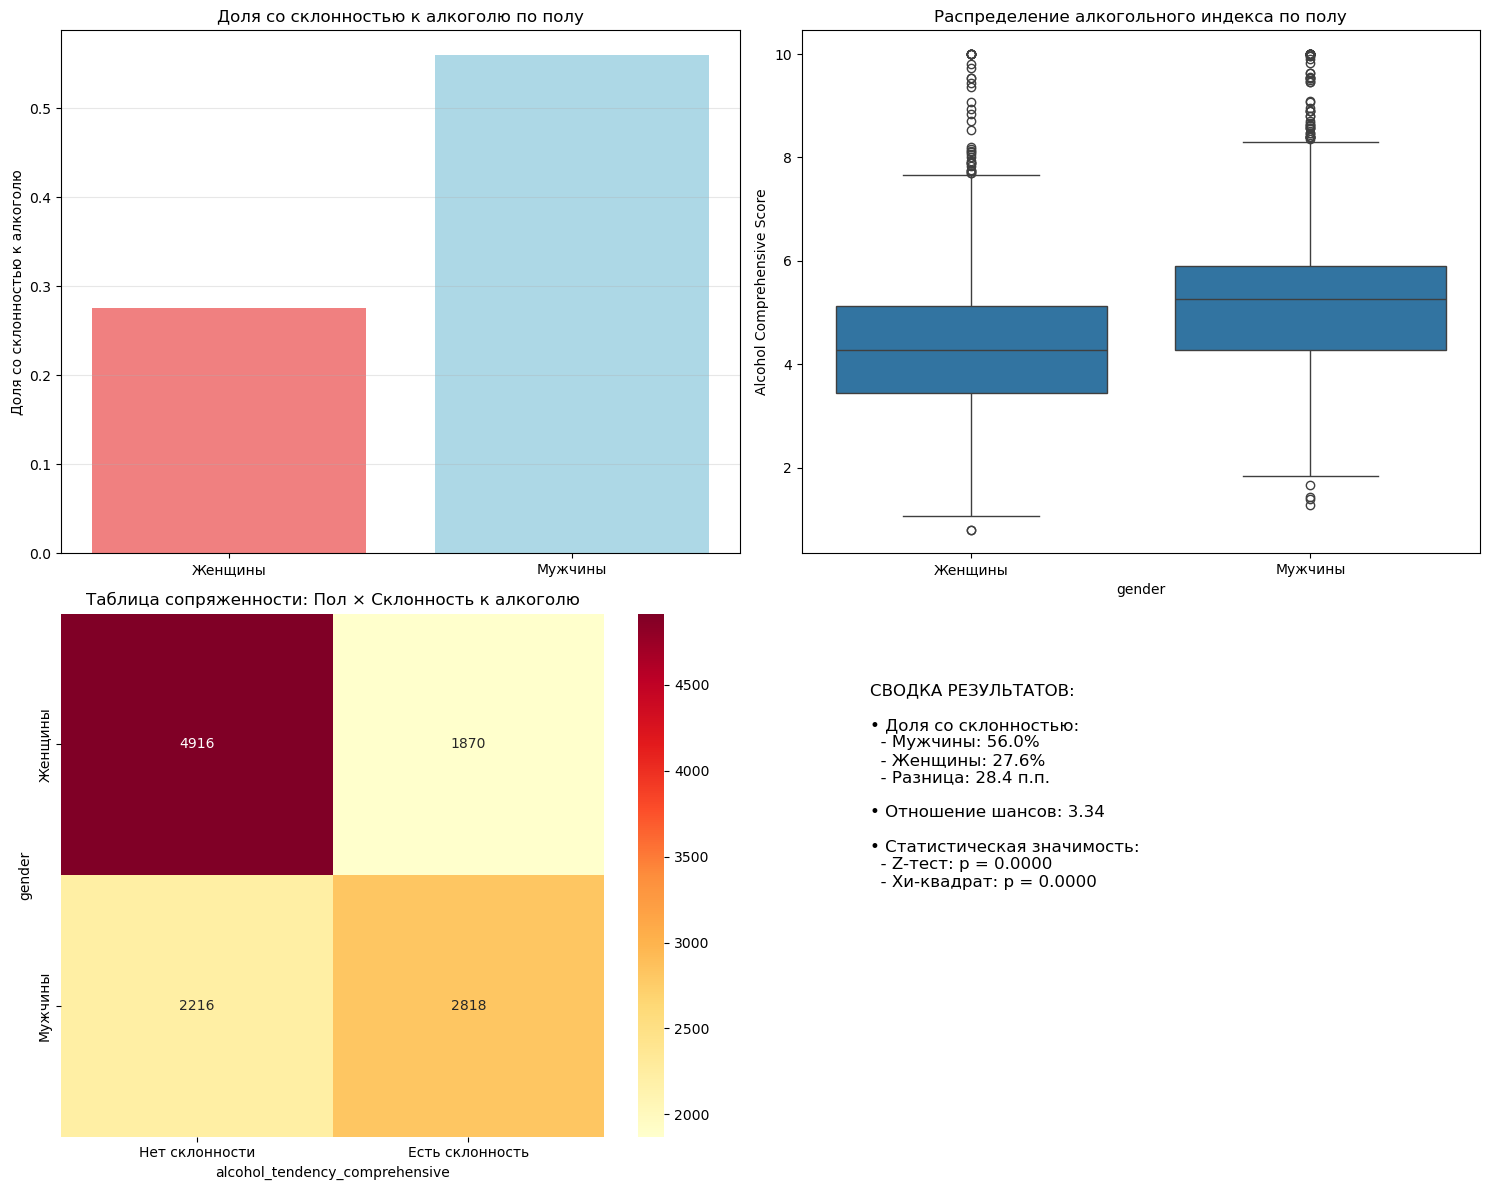

In [34]:
print("=== 1. ДЕСКРИПТИВНАЯ СТАТИСТИКА ===")

# Распределение по полу
gender_dist = df['gender'].value_counts()
print("Распределение по полу:")
print(f"Мужчины: {gender_dist[1]} ({gender_dist[1]/len(df)*100:.1f}%)")
print(f"Женщины: {gender_dist[0]} ({gender_dist[0]/len(df)*100:.1f}%)")

# Доли со склонностью к алкоголю по полу
alcohol_by_gender = df.groupby('gender')['alcohol_tendency_comprehensive'].agg(['mean', 'count'])
print("\nДоля со склонностью к алкоголю:")
print(f"Мужчины: {alcohol_by_gender.loc[1, 'mean']:.3f} ({alcohol_by_gender.loc[1, 'mean']*100:.1f}%)")
print(f"Женщины: {alcohol_by_gender.loc[0, 'mean']:.3f} ({alcohol_by_gender.loc[0, 'mean']*100:.1f}%)")

# Разница в процентах
diff = alcohol_by_gender.loc[1, 'mean'] - alcohol_by_gender.loc[0, 'mean']
print(f"\nРазница: {diff:.3f} ({diff*100:.1f} процентных пункта)")


print("\n=== 2. Z-ТЕСТ ДЛЯ ДВУХ ПРОПОРЦИЙ ===")

# Подготовка данных для Z-теста
count = [alcohol_by_gender.loc[1, 'mean'] * alcohol_by_gender.loc[1, 'count'], 
         alcohol_by_gender.loc[0, 'mean'] * alcohol_by_gender.loc[0, 'count']]
nobs = [alcohol_by_gender.loc[1, 'count'], alcohol_by_gender.loc[0, 'count']]

# Z-тест
z_stat, p_value = proportions_ztest(count, nobs)
print(f"Z-статистика: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Интерпретация
if p_value < 0.05:
    print("✅ Разница СТАТИСТИЧЕСКИ ЗНАЧИМА - гипотеза подтверждается")
else:
    print("❌ Разница НЕ значима - гипотеза не подтверждается")


print("\n=== 3. ОТНОШЕНИЕ ШАНСОВ (ODDS RATIO) ===")

# Расчет шансов
odds_men = alcohol_by_gender.loc[1, 'mean'] / (1 - alcohol_by_gender.loc[1, 'mean'])
odds_women = alcohol_by_gender.loc[0, 'mean'] / (1 - alcohol_by_gender.loc[0, 'mean'])
odds_ratio = odds_men / odds_women

print(f"Шансы для мужчин: {odds_men:.4f}")
print(f"Шансы для женщин: {odds_women:.4f}")
print(f"Отношение шансов (OR): {odds_ratio:.4f}")

# Интерпретация OR
if odds_ratio > 1:
    print(f"✅ Мужчины имеют в {odds_ratio:.2f} раза более высокие шансы склонности к алкоголю")
elif odds_ratio < 1:
    print(f"❌ Женщины имеют в {1/odds_ratio:.2f} раза более высокие шансы")
else:
    print("➖ Шансы равны")


print("\n=== 4. ТЕСТ ХИ-КВАДРАТ ===")

# Создаем таблицу сопряженности
contingency_table = pd.crosstab(df['gender'], df['alcohol_tendency_comprehensive'])
print("Таблица сопряженности:")
print(contingency_table)

# Хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nХи-квадрат: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Степени свободы: {dof}")

if p_value < 0.05:
    print("✅ Есть статистически значимая связь между полом и склонностью к алкоголю")
else:
    print("❌ Связь между полом и склонностью к алкоголю не значима")


print("\n=== 5. T-ТЕСТ ДЛЯ АЛКОГОЛЬНОГО ИНДЕКСА ===")

# Сравниваем alcohol_comprehensive_score
men_score = df[df['gender'] == 1]['alcohol_comprehensive_score'].dropna()
women_score = df[df['gender'] == 0]['alcohol_comprehensive_score'].dropna()

print(f"Средний алкогольный индекс:")
print(f"Мужчины: {men_score.mean():.3f} (std: {men_score.std():.3f})")
print(f"Женщины: {women_score.mean():.3f} (std: {women_score.std():.3f})")
print(f"Разница: {men_score.mean() - women_score.mean():.3f}")

# T-тест
t_stat, p_value = ttest_ind(men_score, women_score, equal_var=False)
print(f"\nT-статистика: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Средние алкогольные индексы значимо различаются")
else:
    print("❌ Разница в средних индексах не значима")



print("\n=== 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Столбчатая диаграмма долей
axes[0, 0].bar(['Женщины', 'Мужчины'], 
               [alcohol_by_gender.loc[0, 'mean'], alcohol_by_gender.loc[1, 'mean']],
               color=['lightcoral', 'lightblue'])
axes[0, 0].set_ylabel('Доля со склонностью к алкоголю')
axes[0, 0].set_title('Доля со склонностью к алкоголю по полу')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Boxplot алкогольного индекса
sns.boxplot(data=df, x='gender', y='alcohol_comprehensive_score', ax=axes[0, 1])
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Женщины', 'Мужчины'])
axes[0, 1].set_title('Распределение алкогольного индекса по полу')
axes[0, 1].set_ylabel('Alcohol Comprehensive Score')

# 3. Тепловая карта таблицы сопряженности
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0])
axes[1, 0].set_title('Таблица сопряженности: Пол × Склонность к алкоголю')
axes[1, 0].set_xticklabels(['Нет склонности', 'Есть склонность'])
axes[1, 0].set_yticklabels(['Женщины', 'Мужчины'])

# 4. Сводка результатов
results_text = f"""
СВОДКА РЕЗУЛЬТАТОВ:

• Доля со склонностью:
  - Мужчины: {alcohol_by_gender.loc[1, 'mean']*100:.1f}%
  - Женщины: {alcohol_by_gender.loc[0, 'mean']*100:.1f}%
  - Разница: {diff*100:.1f} п.п.

• Отношение шансов: {odds_ratio:.2f}

• Статистическая значимость:
  - Z-тест: p = {p_value:.4f}
  - Хи-квадрат: p = {chi2_contingency(pd.crosstab(df['gender'], df['alcohol_tendency_comprehensive']))[1]:.4f}
"""

axes[1, 1].text(0.1, 0.9, results_text, fontsize=12, verticalalignment='top')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# 7. Подготовка данных к обучению моделей

In [37]:
# Выбираем финальные признаки для модели
feature_columns = [
    # Демография
    'age', 'gender', 'education_level',
    
    # Личностные характеристики
    'talkativeness', 'work_accuracy', 'creativity', 'stress_tolerance',
    'task_completion', 'work_ethic', 'forgiveness', 'curiosity',
    'long_term_focus', 'aesthetic_appreciation', 'future_orientation',
    'politeness', 'work_efficiency', 'generosity', 'sociability',
    'decision_carefulness', 'reserved_opinions', 'exploitability',
    'anxiety', 'preference_leisure', 'nervousness', 'perceived_hostility',
    
    # Рисковое поведение
    'general_risk', 'driving_risk', 'financial_risk', 'health_risk',
    'future_sacrifice',
    
    # Здоровье и курение
    'self_rated_health', 'is_smoker'
]

# Убираем отсутствующие колонки
available_features = [col for col in feature_columns if col in df.columns]
print(f"Доступно признаков для модели: {len(available_features)}")

# Создаем финальный датасет для модели
X = df[available_features].select_dtypes(include=[np.number])
y = df['alcohol_tendency_comprehensive']

print(f"Размеры: X {X.shape}, y {y.shape}")

Доступно признаков для модели: 31
Размеры: X (11820, 31), y (11820,)


In [40]:
# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  # сохраняем распределение целевой переменной
)

# 8. Машинное обучение (различные модели)

## 8.1 Random Forest (bagging)

In [44]:
# Инициализация и обучение модели
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'  # важно при несбалансированных данных
)

print("=== ОБУЧЕНИЕ МОДЕЛИ ===")
model.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred_proba = model.predict_proba(X_test)[:, 1]  # вероятности для класса 1

# Применяем порог 0.3
threshold = 0.35
y_pred = (y_pred_proba >= threshold).astype(int)

# Оценка модели
print("\n=== ОЦЕНКА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ ===")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

final_results.append(calculate_comprehensive_metrics(
    y_test, y_pred, y_pred_proba, 'Bagging'
))
# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.3f}")

check_thresholds(y_test,y_pred_proba)

=== ОБУЧЕНИЕ МОДЕЛИ ===

=== ОЦЕНКА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ ===
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      2140
           1       0.67      0.90      0.77      1406

    accuracy                           0.79      3546
   macro avg       0.79      0.81      0.79      3546
weighted avg       0.82      0.79      0.79      3546

Confusion Matrix:
[[1525  615]
 [ 140 1266]]
ROC-AUC Score: 0.906
     threshold        f1  precision    recall
0         0.00  0.567851   0.396503  1.000000
1         0.01  0.567851   0.396503  1.000000
2         0.02  0.569231   0.397849  1.000000
3         0.03  0.574112   0.402635  1.000000
4         0.04  0.579686   0.408377  0.998578
..         ...       ...        ...       ...
96        0.96  0.527473   0.998020  0.358464
97        0.97  0.525930   0.998012  0.357041
98        0.98  0.487910   0.997802  0.322902
99        0.99  0.473142   0.997712  0.310100
100       1

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## 8.2  Gradient Boosting

In [47]:
model_gb = GradientBoostingClassifier(
    n_estimators=100,      # количество деревьев (как в RF)
    max_depth=6,           # максимальная глубина деревьев  
    learning_rate=0.05,     # скорость обучения (типичное значение)
    subsample=0.8,         # доля данных для каждого дерева (как бэггинг)
    random_state=42,       # для воспроизводимости
    verbose=1              # вывод процесса обучения
)

print("=== ОБУЧЕНИЕ GRADIENT BOOSTING ===")
model_gb.fit(X_train, y_train)

# Предсказания с порогом 0.4
y_pred_proba_gb = model_gb.predict_proba(X_test)[:, 1]
threshold = 0.4
y_pred_gb = (y_pred_proba_gb >= threshold).astype(int)

# Метрики
auc_gb = roc_auc_score(y_test, y_pred_proba_gb)

print("\n=== РЕЗУЛЬТАТЫ GRADIENT BOOSTING ===")
print(f"ROC-AUC: {auc_gb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

final_results.append(calculate_comprehensive_metrics(
    y_test, y_pred_gb, y_pred_proba_gb, 'GBoost'
))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

=== ОБУЧЕНИЕ GRADIENT BOOSTING ===
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.2911           0.0516            3.23s
         2           1.2435           0.0447            2.82s
         3           1.2021           0.0483            2.47s
         4           1.1620           0.0350            2.20s
         5           1.1264           0.0372            2.00s
         6           1.0954           0.0425            1.88s
         7           1.0647           0.0274            1.78s
         8           1.0376           0.0321            1.70s
         9           1.0072           0.0066            1.64s
        10           0.9854           0.0347            1.58s
        20           0.8157           0.0010            1.26s
        30           0.7169          -0.0335            1.06s
        40           0.6638           0.0084            0.89s
        50           0.6249           0.0036            0.73s
        60           0.5962       

## 8.3 XGBoosting

In [50]:
# Базовая модель с правильными параметрами
model_xgb = xgb.XGBClassifier(
    n_estimators=100,           # количество деревьев
    max_depth=6,                # глубина деревьев
    learning_rate=0.1,          # скорость обучения
    subsample=0.8,              # доля данных для каждого дерева
    colsample_bytree=0.8,       # доля признаков для каждого дерева
    random_state=42,
    eval_metric='logloss',      # метрика для валидации
    early_stopping_rounds=10,
    verbosity=1
)

print("=== ОБУЧЕНИЕ XGBoost ===")
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10
)

# Предсказания с порогом 0.4
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
threshold = 0.4
y_pred_xgb = (y_pred_proba_xgb >= threshold).astype(int)

# Метрики
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("\n=== РЕЗУЛЬТАТЫ XGBoost ===")
print(f"ROC-AUC: {auc_xgb:.4f}")
print(f"Лучшая итерация: {model_xgb.best_iteration}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

final_results.append(calculate_comprehensive_metrics(
    y_test, y_pred_xgb, y_pred_proba_xgb, 'XGBoost'
))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

=== ОБУЧЕНИЕ XGBoost ===
[0]	validation_0-logloss:0.62545
[10]	validation_0-logloss:0.44147
[20]	validation_0-logloss:0.39035
[30]	validation_0-logloss:0.36938
[40]	validation_0-logloss:0.36406
[50]	validation_0-logloss:0.36179
[60]	validation_0-logloss:0.36088
[70]	validation_0-logloss:0.36127
[73]	validation_0-logloss:0.36146

=== РЕЗУЛЬТАТЫ XGBoost ===
ROC-AUC: 0.9092
Лучшая итерация: 63

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      2140
           1       0.77      0.82      0.79      1406

    accuracy                           0.83      3546
   macro avg       0.82      0.83      0.82      3546
weighted avg       0.83      0.83      0.83      3546


Confusion Matrix:
[[1796  344]
 [ 259 1147]]


## 8.4 Улучшенный XGB (XGBoosting+)

In [53]:
param_grid_xgb = {
    'n_estimators': [100, 200],           # 2 значения
    'max_depth': [4, 6, 8],               # 3 значения  
    'learning_rate': [0.05, 0.1],         # 2 значения
    'subsample': [0.8, 0.9],              # 2 значения
    'colsample_bytree': [0.8, 0.9],       # 2 значения
}

xgb_optimized = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
grid_search_xgb = GridSearchCV(xgb_optimized, param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 0.9],
                         'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200], 'subsample': [0.8, 0.9]},
             scoring='roc_auc')

In [55]:
# Лучшие параметры
print("ЛУЧШИЕ ПАРАМЕТРЫ:")
best_params = grid_search_xgb.best_params_
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Производительность
best_score = grid_search_xgb.best_score_
print(f"\n📊 ПРОИЗВОДИТЕЛЬНОСТЬ:")
print(f"  Лучший AUC (CV): {best_score:.4f}")

# Сравнение с исходной моделью
original_auc = 0.9113
improvement = best_score - original_auc
print(f"\n📈 СРАВНЕНИЕ С ИСХОДНОЙ МОДЕЛЬЮ:")
print(f"  Исходный AUC: {original_auc:.4f}")
print(f"  Улучшение: {improvement:+.4f}")

ЛУЧШИЕ ПАРАМЕТРЫ:
  colsample_bytree: 0.9
  learning_rate: 0.05
  max_depth: 4
  n_estimators: 200
  subsample: 0.8

📊 ПРОИЗВОДИТЕЛЬНОСТЬ:
  Лучший AUC (CV): 0.9111

📈 СРАВНЕНИЕ С ИСХОДНОЙ МОДЕЛЬЮ:
  Исходный AUC: 0.9113
  Улучшение: -0.0002


In [57]:
best_model = grid_search_xgb.best_estimator_
y_pred_proba_optimized = best_model.predict_proba(X_test)[:, 1]

# Применяем порог 0.4
threshold = 0.4
y_pred_optimized = (y_pred_proba_optimized >= threshold).astype(int)

# Оцениваем новое качество
new_auc = roc_auc_score(y_test, y_pred_proba_optimized)

print("\n=== РЕЗУЛЬТАТЫ XGBoost+ ===")
print(f"ROC-AUC: {new_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized))

final_results.append(calculate_comprehensive_metrics(
    y_test, y_pred_optimized, y_pred_proba_optimized, 'XGBoost+'
))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimized))


=== РЕЗУЛЬТАТЫ XGBoost+ ===
ROC-AUC: 0.9098

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      2140
           1       0.77      0.82      0.79      1406

    accuracy                           0.83      3546
   macro avg       0.82      0.83      0.82      3546
weighted avg       0.83      0.83      0.83      3546


Confusion Matrix:
[[1789  351]
 [ 252 1154]]


In [59]:
print("\n=== РЕЗУЛЬТАТЫ XGBoost+ ===")
print(f"ROC-AUC: {auc_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimized))


=== РЕЗУЛЬТАТЫ XGBoost+ ===
ROC-AUC: 0.9092

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      2140
           1       0.77      0.82      0.79      1406

    accuracy                           0.83      3546
   macro avg       0.82      0.83      0.82      3546
weighted avg       0.83      0.83      0.83      3546


Confusion Matrix:
[[1789  351]
 [ 252 1154]]


# 9. Результаты моделей

In [62]:
final_df = pd.DataFrame(final_results)
final_df = final_df.round(4)
final_df = final_df.sort_values('AUC', ascending=False)


In [64]:
final_df

,Model,AUC,Accuracy,Precision,Recall,F1-Score
3,XGBoost+,0.9098,0.8299,0.7668,0.8208,0.7929
1,GBoost,0.9092,0.8263,0.7619,0.8172,0.7886
2,XGBoost,0.9092,0.8299,0.7693,0.8158,0.7919
0,Bagging,0.9056,0.7871,0.6730,0.9004,0.7703


In [66]:
joblib.dump(model, 'model.joblib')

['model.joblib']